# Grafema AI · fine tuning de TinyLlama en Colab

**Objetivo:** escoger el siguiente canto entre diez candidatos reales de la búsqueda semántica, respetando el tema, la energía y lo elegido anteriormente. Repetimos la elección de **5 a 9 veces** para armar un servicio completo. Las canciones siguen viniendo de la API de Grafema AI y Supabase; el modelo aprende a elegir y justificar, no memoriza el catálogo.

El JSONL contiene **76 servicios y 532 elecciones de momento**.

## 1. Preparar bibliotecas

TRL calcula la pérdida sobre la respuesta humana; PEFT y bitsandbytes entrenan adaptadores pequeños con el modelo base en 4 bits. Colab puede pedir que reinicies el entorno tras instalar: hazlo antes de seguir.

In [ ]:
%pip -q install -U 'transformers>=4.55,<5' 'trl>=0.25,<0.28' 'peft>=0.17,<0.20' 'datasets>=3.5,<5' 'accelerate>=1.5,<2' 'bitsandbytes>=0.45,<0.50' huggingface_hub

## 2. Confirmar la GPU y montar Drive

TinyLlama es público; **HF_TOKEN es opcional**. Montamos Drive para guardar el adaptador final y las métricas. Los checkpoints temporales se escriben en la máquina de Colab para que el entrenamiento sea más rápido.

In [ ]:
import torch
from pathlib import Path
from google.colab import drive, userdata
from huggingface_hub import login

assert torch.cuda.is_available(), 'Selecciona una GPU NVIDIA en Colab.'
print('GPU:', torch.cuda.get_device_name(0), '| GiB:', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))
try:
    token = userdata.get('HF_TOKEN')
except Exception:
    token = None
if token:
    login(token=token, add_to_git_credential=False)
    del token
drive.mount('/content/drive')
DEST = Path('/content/drive/MyDrive/grafema_ai/tinyllama_servicios_qlora')
DEST.mkdir(parents=True, exist_ok=True)
print('Resultados:', DEST)

GPU: Tesla T4 | GiB: 14.6
Mounted at /content/drive
Resultados: /content/drive/MyDrive/grafema_ai/tinyllama_servicios_qlora


## 3. Subir y validar los servicios revisados

Cada línea trae solicitud, candidatos y la selección revisada. Exigimos que la respuesta tenga el mismo número y orden de momentos que la solicitud y que cada ID esté dentro de los diez candidatos **de su momento**. Cualquier línea inválida detiene el proceso.

In [ ]:
import json
from google.colab import files

uploaded = files.upload()
assert 'grafema-services-reviewed.jsonl' in uploaded, 'Sube grafema-services-reviewed.jsonl.'
raw_rows = []
issues = []
generic_reasons = 0
for line_number, line in enumerate(uploaded['grafema-services-reviewed.jsonl'].decode('utf-8').splitlines(), 1):
    if not line.strip():
        continue
    try:
        row = json.loads(line)
        assert [m['role'] for m in row['messages']] == ['system', 'user', 'assistant']
        source = json.loads(row['messages'][1]['content'])
        choices = json.loads(row['messages'][2]['content'])['items']
        groups = source['candidates']
        assert len(groups) == len(choices) == int(source['request']['count'])
        assert len(set(item['songId'] for item in choices)) == len(choices), 'canto repetido'
        for group, choice in zip(groups, choices):
            assert group['stage'] == choice['stage'], 'etapa en otro orden'
            assert any(o['id'] == choice['songId'] for o in group['options']), 'canto no encontrado en su momento'
            assert len(group['options']) > 0
            generic_reasons += ('revisa su letra' in choice.get('reason', '').lower() or
                                'coincide con' in choice.get('reason', '').lower())
        raw_rows.append(row)
    except Exception as exc:
        issues.append((line_number, str(exc)))
print('Servicios:', len(raw_rows), '| decisiones:', sum(len(json.loads(r['messages'][2]['content'])['items']) for r in raw_rows))
print('Motivos genéricos a revisar posteriormente:', generic_reasons, '| errores:', issues[:5])
assert not issues and len(raw_rows) >= 20, 'Corrige las líneas indicadas antes de entrenar.'

Saving grafema-services-reviewed.jsonl to grafema-services-reviewed.jsonl
Servicios: 76 | decisiones: 532
Motivos genéricos a revisar posteriormente: 66 | errores: []


## 4. Transformar servicios en elecciones sucesivas

Cada servicio genera un ejemplo por momento: `{request, current, previous}`. `previous` contiene los cantos elegidos **antes** del momento actual; no revela el canto que estamos tratando de predecir. La respuesta conserva el ID y el motivo revisado. Todas las opciones del momento están presentes; la evidencia y las etiquetas se acortan solo si la longitud supera el límite real de tokens. La misma función sirve después para inferencia en la API.

In [ ]:
import re

SYSTEM = ('Elige UN canto real para current entre sus options. Devuelve SOLO JSON con '
          '{"songId":"...","reason":"..."}. Nunca inventes IDs ni repitas los de previous. '
          'Usa tema, enfoque, ocasión, energía del momento y secuencia previa.')

def build_step(request, group, previous, evidence_chars=90, top_tags=3):
    options = []
    for item in group['options']:
        tags = item.get('tags') or {}
        ranked = sorted(((key, value) for key, value in tags.items() if isinstance(value, (int, float))),
                        key=lambda pair: (-pair[1], pair[0]))[:top_tags]
        options.append({'id': item['id'], 'title': item['title'],
                        'evidence': re.sub(r'\s+', ' ', item.get('evidence') or '').strip()[:evidence_chars],
                        'energy': item.get('energy'), 'tags': dict(ranked)})
    return {'request': request, 'current': {'key': group['key'], 'stage': group['stage'],
            'targetEnergy': group.get('targetEnergy'), 'options': options}, 'previous': previous}

def service_steps(raw_row, evidence_chars=90, top_tags=3):
    user = json.loads(raw_row['messages'][1]['content'])
    gold = json.loads(raw_row['messages'][2]['content'])['items']
    previous, samples = [], []
    for group, choice in zip(user['candidates'], gold):
        step = build_step(user['request'], group, previous, evidence_chars, top_tags)
        prompt = [{'role': 'system', 'content': SYSTEM},
                  {'role': 'user', 'content': json.dumps(step, ensure_ascii=False, separators=(',', ':'))}]
        completion = [{'role': 'assistant', 'content': json.dumps({
            'songId': choice['songId'], 'reason': choice['reason']}, ensure_ascii=False, separators=(',', ':'))}]
        samples.append({'prompt': prompt, 'completion': completion})
        selected = next(o for o in group['options'] if o['id'] == choice['songId'])
        previous = previous + [{'stage': group['stage'], 'songId': choice['songId'],
                                'title': selected['title'], 'energy': selected.get('energy')}]
    return samples

print('Momentos del primer servicio:', len(service_steps(raw_rows[0])))
print('Primera entrada:', service_steps(raw_rows[0])[0]['prompt'][1]['content'][:700])

Momentos del primer servicio: 7
Primera entrada: {"request":{"count":7,"focus":"","notes":"","theme":"Esperanza en medio de las dificultades","recipe":"descendente","specialOccasion":""},"current":{"key":"s1-1","stage":"Apertura","targetEnergy":5,"options":[{"id":"1762098488191-6v6ex3a3k","title":"En un aposento alto","evidence":"En un aposento alto, Con unánime fervor, Ciento veinte esperaban La promesa del Señor. Dio","energy":4.78,"tags":{"espiritu_santo":0.97,"fe":0.88,"esperanza":0.83}},{"id":"1762098507623-qj7vsoqsj","title":"Al sonar de la trompeta","evidence":"Al sonar de la trompeta, nuestro corazón despierta, Es Jesús que en las nubes viene ya; De","energy":4.99,"tags":{"segunda_venida":0.99,"eternidad":0.97,"jesucristo":0.97}},{


## 5. Medir longitud con el tokenizador de TinyLlama

El tokenizador declara **2048 tokens**, incluyendo prompt y respuesta. Elegimos la mayor cantidad de evidencia/etiquetas que permita terminar todos los ejemplos sin truncar. Reservamos además espacio para generar la respuesta en evaluación. Si algún caso no cabe incluso sin evidencia, detenemos el entrenamiento.

In [ ]:
from transformers import AutoTokenizer
import numpy as np

MODEL_ID = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
MAX_LENGTH = 2048
MAX_NEW_TOKENS = 200
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

def lengths(sample):
    p = tokenizer.apply_chat_template(sample['prompt'], tokenize=True, add_generation_prompt=True)
    full = tokenizer.apply_chat_template(sample['prompt'] + sample['completion'], tokenize=True,
                                         add_generation_prompt=False)
    return len(p), len(full)

for evidence_chars, top_tags in [(120, 3), (90, 2), (55, 1), (20, 0), (0, 0)]:
    grouped = [service_steps(row, evidence_chars, top_tags) for row in raw_rows]
    counts = [lengths(sample) for service in grouped for sample in service]
    if max(total for _, total in counts) <= MAX_LENGTH and max(p for p, _ in counts) + MAX_NEW_TOKENS <= MAX_LENGTH:
        break
print('Evidencia por opción:', evidence_chars, '| etiquetas:', top_tags)
print('Máximo tokens entrada:', max(p for p, _ in counts), '| entrada + respuesta:', max(t for _, t in counts))
print('Percentiles entrada + respuesta:', np.percentile([t for _, t in counts], [0, 50, 90, 100]).astype(int))
assert max(t for _, t in counts) <= MAX_LENGTH, 'Ni sin evidencia cabe: revisar request/previous o elegir un modelo de contexto mayor.'
assert max(p for p, _ in counts) + MAX_NEW_TOKENS <= MAX_LENGTH, 'No hay espacio para generar: reducir información del prompt.'
assert all(t > p + 3 for p, t in counts), 'Respuesta vacía en algún ejemplo.'
CONTRACT = {'model_id': MODEL_ID, 'system': SYSTEM, 'max_length': MAX_LENGTH,
            'max_new_tokens': MAX_NEW_TOKENS, 'evidence_chars': evidence_chars,
            'top_tags': top_tags, 'input_format': '{request,current,previous}',
            'output_format': '{songId,reason}', 'role_format': 'conversational prompt-completion'}
(DEST / 'prompt_contract.json').write_text(json.dumps(CONTRACT, ensure_ascii=False, indent=2), encoding='utf-8')

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Evidencia por opción: 120 | etiquetas: 3
Máximo tokens entrada: 1820 | entrada + respuesta: 1954
Percentiles entrada + respuesta: [1378 1616 1785 1954]


528

## 6. Separar por tema y ocasión ANTES de dividir en momentos

Una división por momentos mezclaría las decisiones de un mismo servicio entre entrenamiento y prueba. Dividimos primero por tema y ocasión: los servicios completos de prueba no enseñan nada al modelo durante el ajuste.

In [ ]:
from collections import defaultdict
from datasets import Dataset
import random

by_topic = defaultdict(list)
for i, row in enumerate(raw_rows):
    request = json.loads(row['messages'][1]['content'])['request']
    key = (request.get('theme', '').strip().casefold(), request.get('specialOccasion', '').strip().casefold())
    by_topic[key].append(i)
topics = list(by_topic)
assert len(topics) >= 10
random.Random(42).shuffle(topics)
n_holdout = max(2, round(len(topics) * .15))
test_topics = set(topics[:n_holdout]); eval_topics = set(topics[n_holdout:2*n_holdout])
train_topics = set(topics[2*n_holdout:])
def group_indices(topic_set):
    return [index for topic in sorted(topic_set) for index in by_topic[topic]]
train_index, eval_index, test_index = [group_indices(s) for s in (train_topics, eval_topics, test_topics)]
train_ds = Dataset.from_list([sample for i in train_index for sample in grouped[i]])
eval_ds = Dataset.from_list([sample for i in eval_index for sample in grouped[i]])
test_services = [(raw_rows[i], grouped[i]) for i in test_index]
print('Momentos entrenamiento / validación:', len(train_ds), len(eval_ds))
print('Servicios prueba:', len(test_services), '| momentos prueba:', sum(len(samples) for _, samples in test_services))
assert set(train_index).isdisjoint(eval_index + test_index)
assert len(train_index) + len(eval_index) + len(test_index) == len(raw_rows)

Momentos entrenamiento / validación: 322 105
Servicios prueba: 15 | momentos prueba: 105


## 7. Cargar TinyLlama en 4 bits

NF4 reduce el peso del modelo; `prepare_model_for_kbit_training()` congela los pesos cuantizados y prepara el ajuste de adaptadores LoRA. Mantén un **único modelo cargado** en la GPU durante todo el cuaderno.

In [ ]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training

dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                          bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=dtype)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=quant,
                                             device_map={'': 0}, torch_dtype=dtype)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)
print('Base cargada:', MODEL_ID)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Base cargada: TinyLlama/TinyLlama-1.1B-Chat-v1.0


## 8. Medición inicial sin entrenamiento

Comprobamos hasta cinco decisiones de servicios de prueba. Para comparar en igualdad de condiciones, el contexto `previous` contiene las selecciones revisadas **anteriores** a la decisión evaluada, tanto antes como después del entrenamiento. La última celda muestra cómo generar un servicio completo usando las decisiones del propio modelo.

In [ ]:
import gc

COMPARE = [(row, sample) for row, samples in test_services for sample in samples][:5]
assert COMPARE

def generate_one(active_model, prompt):
    active_model.eval()
    encoded = tokenizer.apply_chat_template(prompt, tokenize=True, add_generation_prompt=True,
                                            return_tensors='pt').to('cuda')
    assert encoded.shape[-1] + MAX_NEW_TOKENS <= MAX_LENGTH
    with torch.inference_mode():
        output = active_model.generate(encoded, do_sample=False, max_new_tokens=MAX_NEW_TOKENS,
                                       pad_token_id=tokenizer.eos_token_id,
                                       eos_token_id=tokenizer.eos_token_id)
    result = tokenizer.decode(output[0][encoded.shape[-1]:], skip_special_tokens=True)
    del encoded, output
    return result

def score(text, sample):
    payload = json.loads(sample['prompt'][1]['content'])
    gold = json.loads(sample['completion'][0]['content'])
    result = {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}
    try:
        choice = json.loads(text.strip())
        result['json'] = isinstance(choice, dict)
        song_id = choice['songId']
        result['valid_id'] = song_id in {o['id'] for o in payload['current']['options']}
        result['unique'] = song_id not in {p['songId'] for p in payload['previous']}
        result['exact_id'] = song_id == gold['songId']
        result['has_reason'] = bool(choice.get('reason', '').strip())
    except (ValueError, KeyError, AttributeError, TypeError):
        pass
    return result

baseline = []
for idx, (_, sample) in enumerate(COMPARE, 1):
    baseline.append(score(generate_one(model, sample['prompt']), sample))
    print(f'Base {idx}/{len(COMPARE)}:', baseline[-1])
(DEST / 'baseline.json').write_text(json.dumps(baseline, indent=2), encoding='utf-8')
gc.collect(); torch.cuda.empty_cache()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base 1/5: {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}
Base 2/5: {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}
Base 3/5: {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}
Base 4/5: {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}
Base 5/5: {'json': False, 'valid_id': False, 'unique': False, 'exact_id': False, 'has_reason': False}


## 9. Entrenar QLoRA (solo la decisión revisada)

`completion_only_loss=True` aprende el canto elegido y el motivo; no premia copiar los candidatos. La secuencia máxima es **2048**, no 8192. LoRA solo entrena proyecciones de atención `q_proj` y `v_proj` para reducir memoria. Dos épocas y el lote 1 son un punto de partida; observa la pérdida de validación y evita confiar solo en la pérdida de entrenamiento.

In [ ]:
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

lora = LoraConfig(r=8, lora_alpha=16, lora_dropout=.05, bias='none',
                  task_type='CAUSAL_LM', target_modules=['q_proj', 'v_proj'])
args = SFTConfig(output_dir='/content/grafema_tinyllama_checkpoints',
                 max_length=MAX_LENGTH, completion_only_loss=True, packing=False,
                 num_train_epochs=2, per_device_train_batch_size=1, per_device_eval_batch_size=1,
                 gradient_accumulation_steps=4, gradient_checkpointing=True,
                 learning_rate=1e-4, lr_scheduler_type='cosine', warmup_ratio=.1,
                 optim='paged_adamw_8bit', fp16=(dtype == torch.float16), bf16=(dtype == torch.bfloat16),
                 logging_steps=10, eval_strategy='epoch', save_strategy='epoch',
                 save_total_limit=2, report_to='none', seed=42)
trainer = SFTTrainer(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds,
                     processing_class=tokenizer, peft_config=lora)
train_result = trainer.train()
print('Entrenamiento:', train_result.metrics)
print('Validación final:', trainer.evaluate())

Tokenizing train dataset:   0%|          | 0/322 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/322 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/105 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Epoch,Training Loss,Validation Loss
1,1.015100,1.052178
2,0.950200,1.013262


Entrenamiento: {'train_runtime': 5232.1775, 'train_samples_per_second': 0.123, 'train_steps_per_second': 0.031, 'total_flos': 6517974959529984.0, 'train_loss': 1.10074457415828}


Validación final: {'eval_loss': 1.0132619142532349, 'eval_runtime': 258.7033, 'eval_samples_per_second': 0.406, 'eval_steps_per_second': 0.406}


## 10. Guardar adaptador y curva de pérdida

Guardamos **solo el adaptador LoRA** y el tokenizador. Para cargarlo en otra máquina también necesitarás TinyLlama base. Drive conserva estos archivos cuando Colab cierra la sesión.

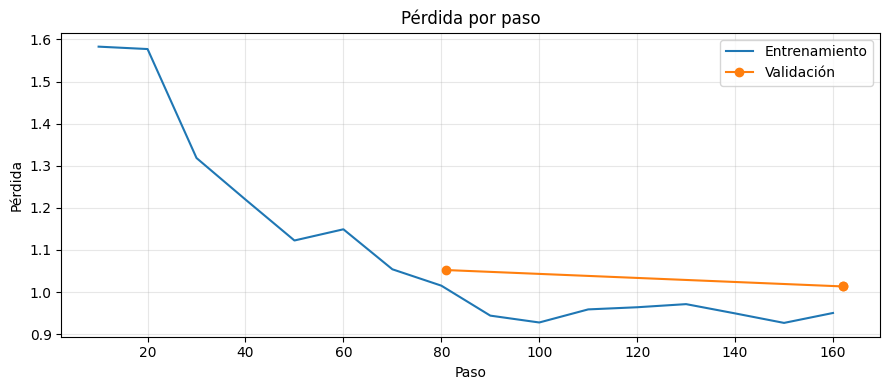

Guardado: /content/drive/MyDrive/grafema_ai/tinyllama_servicios_qlora/adapter


In [ ]:
import matplotlib.pyplot as plt

ADAPTER_DIR = DEST / 'adapter'
trainer.save_model(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
history = trainer.state.log_history
(DEST / 'training_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
train_points = [(r['step'], r['loss']) for r in history if 'loss' in r]
eval_points = [(r['step'], r['eval_loss']) for r in history if 'eval_loss' in r]
plt.figure(figsize=(9, 4))
if train_points:
    plt.plot(*zip(*train_points), label='Entrenamiento')
if eval_points:
    plt.plot(*zip(*eval_points), 'o-', label='Validación')
plt.title('Pérdida por paso'); plt.xlabel('Paso'); plt.ylabel('Pérdida')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(DEST / 'loss.png', dpi=150); plt.show()
print('Guardado:', ADAPTER_DIR)

## 11. Comparar con la base usando los mismos cinco casos

JSON válido, ID candidato, ausencia de repetición y coincidencia con la revisión humana son mediciones distintas. Una elección diferente a la revisada puede ser válida: **revisa la letra, energía y motivos** antes de sacar conclusiones.

In [ ]:
tuned = []
for idx, (_, sample) in enumerate(COMPARE, 1):
    tuned.append(score(generate_one(trainer.model, sample['prompt']), sample))
    print(f'Ajustado {idx}/{len(COMPARE)}:', tuned[-1])

def summarize(results):
    return {k: f'{sum(bool(r[k]) for r in results)}/{len(results)}' for k in results[0]}

comparison = {'model_id': MODEL_ID, 'evaluated_decisions': len(COMPARE),
              'base': summarize(baseline), 'adjusted': summarize(tuned),
              'base_cases': baseline, 'adjusted_cases': tuned}
(DEST / 'comparison.json').write_text(json.dumps(comparison, indent=2), encoding='utf-8')
print(json.dumps({'base': comparison['base'], 'adjusted': comparison['adjusted']}, indent=2))

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Ajustado 1/5: {'json': True, 'valid_id': True, 'unique': True, 'exact_id': True, 'has_reason': True}
Ajustado 2/5: {'json': True, 'valid_id': True, 'unique': True, 'exact_id': True, 'has_reason': True}
Ajustado 3/5: {'json': True, 'valid_id': True, 'unique': True, 'exact_id': True, 'has_reason': True}
Ajustado 4/5: {'json': True, 'valid_id': True, 'unique': True, 'exact_id': True, 'has_reason': True}
Ajustado 5/5: {'json': True, 'valid_id': True, 'unique': True, 'exact_id': True, 'has_reason': True}
{
  "base": {
    "json": "0/5",
    "valid_id": "0/5",
    "unique": "0/5",
    "exact_id": "0/5",
    "has_reason": "0/5"
  },
  "adjusted": {
    "json": "5/5",
    "valid_id": "5/5",
    "unique": "5/5",
    "exact_id": "5/5",
    "has_reason": "5/5"
  }
}


## 12. Armar un servicio completo a partir de la búsqueda (prueba)

La API de Grafema AI debe devolver los `candidates` de cada momento. `build_step()` forma el prompt de cada decisión. Aquí usamos **un servicio reservado** como simulación de la búsqueda y alimentamos al siguiente momento las selecciones del modelo, sin usar las respuestas revisadas. Si la salida no es válida, se detiene: un servidor real debería reintentar o elegir un candidato de manera controlada, nunca aceptar IDs inventados.

In [ ]:
demo_row, _ = test_services[0]
demo = json.loads(demo_row['messages'][1]['content'])
previous = []
for group in demo['candidates']:
    step = build_step(demo['request'], group, previous, evidence_chars, top_tags)
    prompt = [{'role': 'system', 'content': SYSTEM},
              {'role': 'user', 'content': json.dumps(step, ensure_ascii=False, separators=(',', ':'))}]
    output = generate_one(trainer.model, prompt)
    try:
        choice = json.loads(output.strip())
        selected = next(o for o in group['options'] if o['id'] == choice['songId']
                        and o['id'] not in {p['songId'] for p in previous})
    except (ValueError, KeyError, TypeError, StopIteration) as exc:
        print('Salida inválida en', group['stage'], '→', output)
        raise RuntimeError('Revisar esta elección antes de continuar.') from exc
    previous.append({'stage': group['stage'], 'songId': selected['id'],
                     'title': selected['title'], 'energy': selected.get('energy')})
    print(group['stage'], '→', selected['title'], '|', choice.get('reason', ''))
print('Servicio generado:', len(previous), 'cantos')

Apertura → Todas las promesas del Señor Jesús | Este canto es una promesa de confianza y apoyo, que ayuda a la iglesia a seguir a Jesús y su promesa de amor y bendición. Su energía es adecuada para el culto dominical.
Apertura → Cantaremos alabanzas | Este canto es una alabanza congregacional que invita a la participación de toda la iglesia, con una energía de 3.95, y su letra es una promesa de amor y confianza en Dios, que es ideal para la apertura.
Preparación → Que dulces promesas son | Este canto es una promesa de confianza y esperanza, que se adapta a la preparación de la iglesia y su preparación para la fe. Su energía es adecuada para la fase de preparación, y su tema es la fe para confiar en las promesas de Dios.
Preparación → Himno de la familia pastoral | Este himno es una promesa de la familia pastoral, que se prepara para la preocupación de la iglesia, y su energía es adecuada para el momento.
Respuesta → Creo en ti | Este canto es una promesa de confianza y esperanza, que s

In [ ]:
#Publicar a Hugging face
from google.colab import userdata
from huggingface_hub import HfApi
from pathlib import Path


api = HfApi(token=userdata.get("HF_WRITE_TOKEN"))
usuario = api.whoami()["name"]
repo_id = f"{usuario}/grafema-tinyllama-servicios"
DEST = Path('/content/drive/MyDrive/grafema_ai/tinyllama_servicios_qlora')
ADAPTER_DIR = DEST / 'adapter'

api.create_repo(repo_id, repo_type="model", private=False, exist_ok=True)
api.upload_folder(
    folder_path=str(ADAPTER_DIR),
    repo_id=repo_id,
    repo_type="model",
)
api.upload_file(
    path_or_fileobj=str(DEST / "prompt_contract.json"),
    path_in_repo="prompt_contract.json",
    repo_id=repo_id,
    repo_type="model",
)
print(f"https://huggingface.co/{repo_id}")

ValueError: Provided path: '/content/drive/MyDrive/grafema_ai/tinyllama_servicios_qlora/adapter' is not a directory